In [12]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bhagyesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
# Load CSV (skip the first unnamed column)
data = pd.read_csv(r'C:\Users\Bhagyesh\Downloads\temp\spam_ham_dataset.csv', encoding='latin-1', index_col=0)

In [14]:
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'(?i)subject:', '', text)
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [15]:
# Apply preprocessing
data['text'] = data['text'].apply(preprocess_text)

In [16]:
# Features and labels
X = data['text']
y = data['label']  # <-- Use 'ham'/'spam'

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       735
        spam       0.97      0.96      0.96       300

    accuracy                           0.98      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.98      0.98      0.98      1035



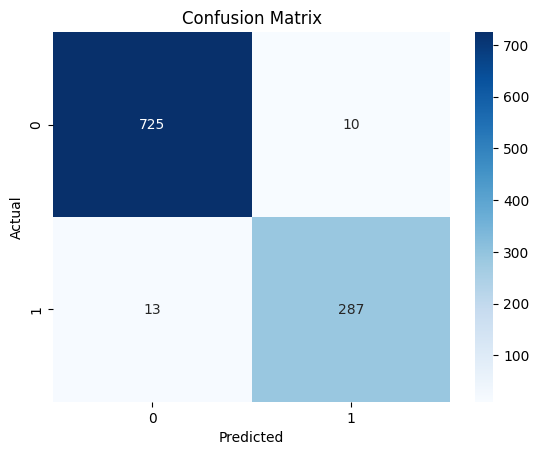

spam


In [ ]:
# Predict and evaluate
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))

joblib.dump(model, 'spam_classifier_model.joblib')
joblib.dump(vectorizer, 'spam_vectorizer.joblib')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Predict on a new email
def predict_email(text):
    text = preprocess_text(text)
    vect = vectorizer.transform([text])
    prediction = model.predict(vect)
    return prediction[0]  # 'spam' or 'ham'

print(predict_email("Hello bhagyesh tommorow we have a meeting"))

In [ ]:

# Predict on a new email
def predict_email(text):
    text = preprocess_text(text)
    vect = vectorizer.transform([text])
    prediction = model.predict(vect)
    return prediction[0]  # 'spam' or 'ham'

print(predict_email("Subject: hpl nom for january 9 , 2001"))

ham
